In [ ]:
import bayco
import pandas as pd

In [ ]:
# import the example data and lists
dataset1 = pd.read_csv("../example_data/DATASET1_5000gene_10_timepoints.csv")
dataset2 = pd.read_csv("../example_data/DATASET2_5000gene_12_timepoints_4clusters.csv")
dataset3 = pd.read_csv("../example_data/DATASET3_5000gene_10_timepoints_3clusters_someBGcoexpression.csv")

all_genes_list = pd.read_csv("../example_data/all_genes_list.csv")["Gene"].to_list()

In [ ]:
# prepare the data
prepared_dataset1 = bayco.df_to_prepareddf(dataset1, 1)
prepared_dataset2 = bayco.df_to_prepareddf(dataset2, 1)
prepared_dataset3 = bayco.df_to_prepareddf(dataset3, 1)

In [ ]:
# making the networks
## testing showed 5000 is the minimum sample size of pairs for a representative background distirbution so will use here for a fast examplw run
dataset1_network = bayco.df_to_BFs_allgenes(all_genes_list , prepared_dataset1, 5000, mode='positive')
dataset2_network = bayco.df_to_BFs_allgenes(all_genes_list , prepared_dataset2, 5000, mode='positive')
dataset3_network = bayco.df_to_BFs_allgenes(all_genes_list , prepared_dataset3, 5000, mode='positive')

In [ ]:
# combining the networks 
network_list = [dataset1_network, dataset2_network, dataset3_network]
combined_123_network = bayco.combine_networks(network_list)

In [ ]:
# the network can now be saved 
combined_123_network.to_csv("all_gene_pairs_combined_network_example.csv", index = False)

## Below is a quick plot of the resulting network

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

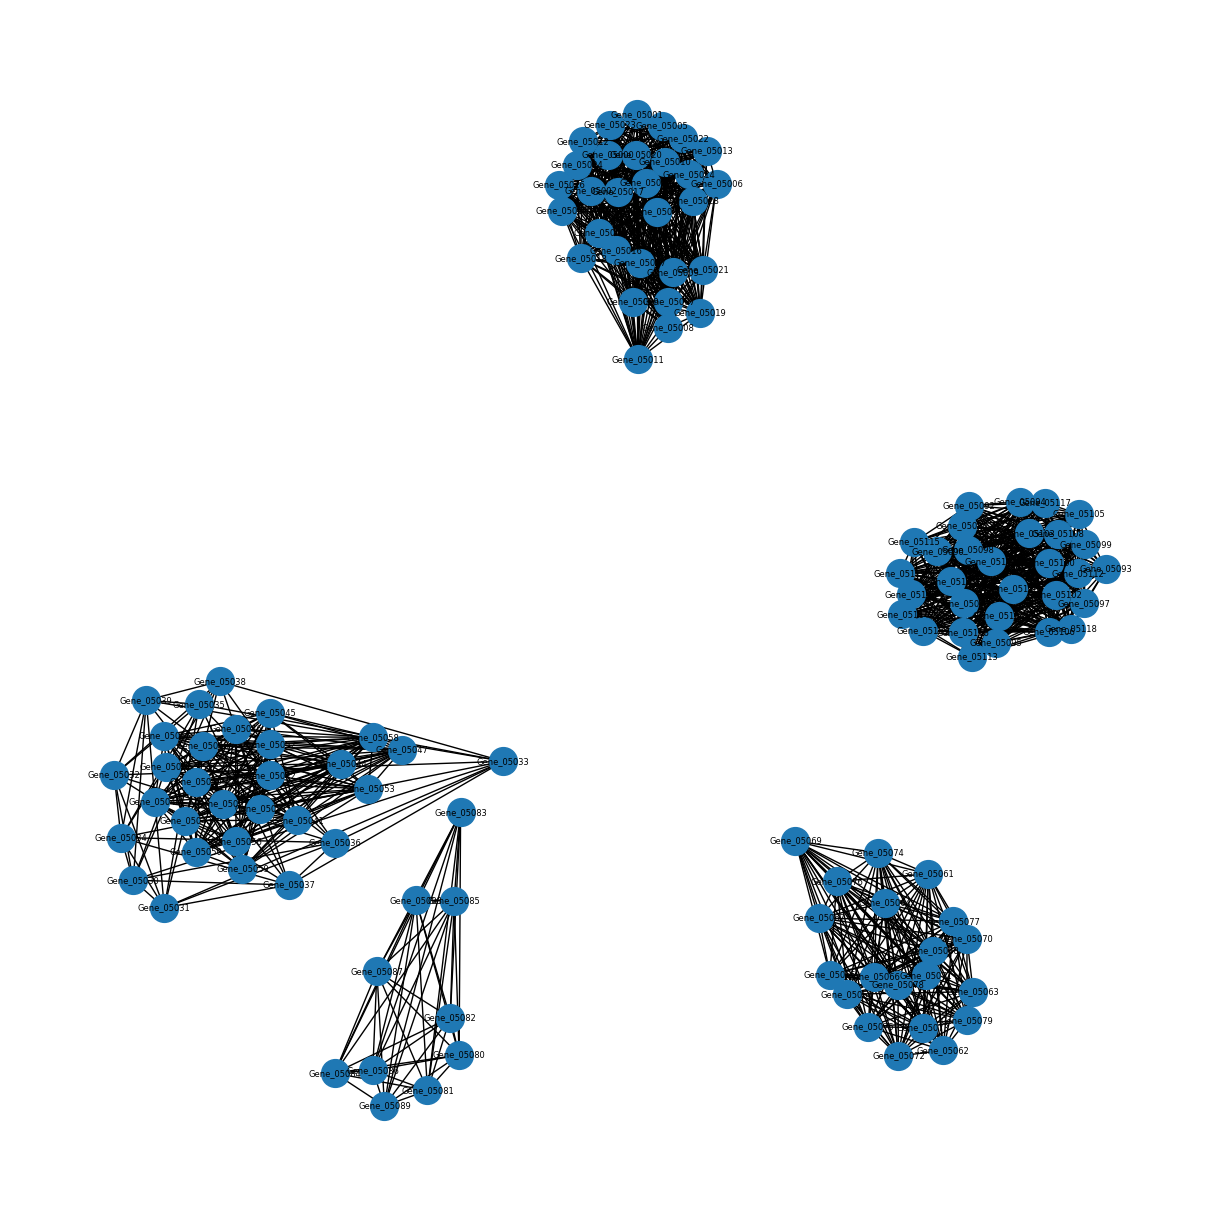

In [ ]:
# keep edges log10BF > 1 
adj = combined_123_network.where(combined_123_network > 1, 0)

# make graph
G = nx.from_pandas_adjacency(adj)

# spread nodes out
pos = nx.spring_layout(G, k=2, iterations=100)

# plot
plt.figure(figsize=(12, 12))
nx.draw(
   G,
    pos,
    with_labels=True,
    node_size=400,
    font_size=6
)

plt.show()